# ERA5 Verification for the 2022 Lake Effect Snowstorm

This notebook will use ERA5 data to see how the November 2022 Lake Effect Storm was handled for reanalysis.

Specifically, this notebook will look at snow depth and 2m temperature.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import datetime as dt
from metpy.units import units
import metpy.calc as mpcalc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib

Setting up the dates for our event.

In [2]:
start_date = '20221117/00'
end_date = '20221120/00'

interval_hours = 6

interval_hours = dt.timedelta(hours=interval_hours)
sdate = dt.datetime.strptime(start_date,'%Y%m%d/%H')
edate = dt.datetime.strptime(end_date,'%Y%m%d/%H') + interval_hours

yyyymm = dt.datetime.strftime(sdate,'%Y%m')

And now opening the data set!

In [3]:
ds = xr.open_dataset(
  'https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr', 
  chunks={}, storage_options={"client_kwargs":{"trust_env":True}}, consolidated=True, engine="zarr"
  )
data = ds.sel(valid_time=slice(sdate, edate))

Setting up the areal extent.

In [4]:
lonW = -81
lonE = -72
latS = 40
latN = 47
cLat, cLon = (latS + latN)/2, (lonW + lonE)/2

# converting to conventional longitude format
if (lonW < 0 ):
    lonW = lonW + 360
if (lonE < 0 ):
    lonE = lonE + 360
    
expand = 1
latRange = np.arange(latS - expand,latN + expand,.25)
lonRange = np.arange((lonW - expand),(lonE + expand),.25)

# further limiting our data set to contain just the desired latitude and longitude ranges
data = data.sel(latitude=latRange,longitude=lonRange)
data

<xarray.Dataset> Size: 64MB
Dimensions:     (valid_time: 79, latitude: 36, longitude: 44)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 632B 2022-11-17 ... 2022-11-20T06...
  * latitude    (latitude) float64 288B 39.0 39.25 39.5 ... 47.25 47.5 47.75
  * longitude   (longitude) float64 352B 278.0 278.2 278.5 ... 288.2 288.5 288.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/128)
    alnid       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 501kB dask.array<chunksize=(79, 36, 44), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Extracting the variables of interest.

In [5]:
snowfall = data['sf'] * 1e3
depth = data['sd'] * 1e3
u100 = data['u100']
v100 = data['v100']
temp = data['t2m']
temp = (temp - 273.15) * 9/5 + 32
lats = temp.latitude
lons = temp.longitude

And finally plotting!

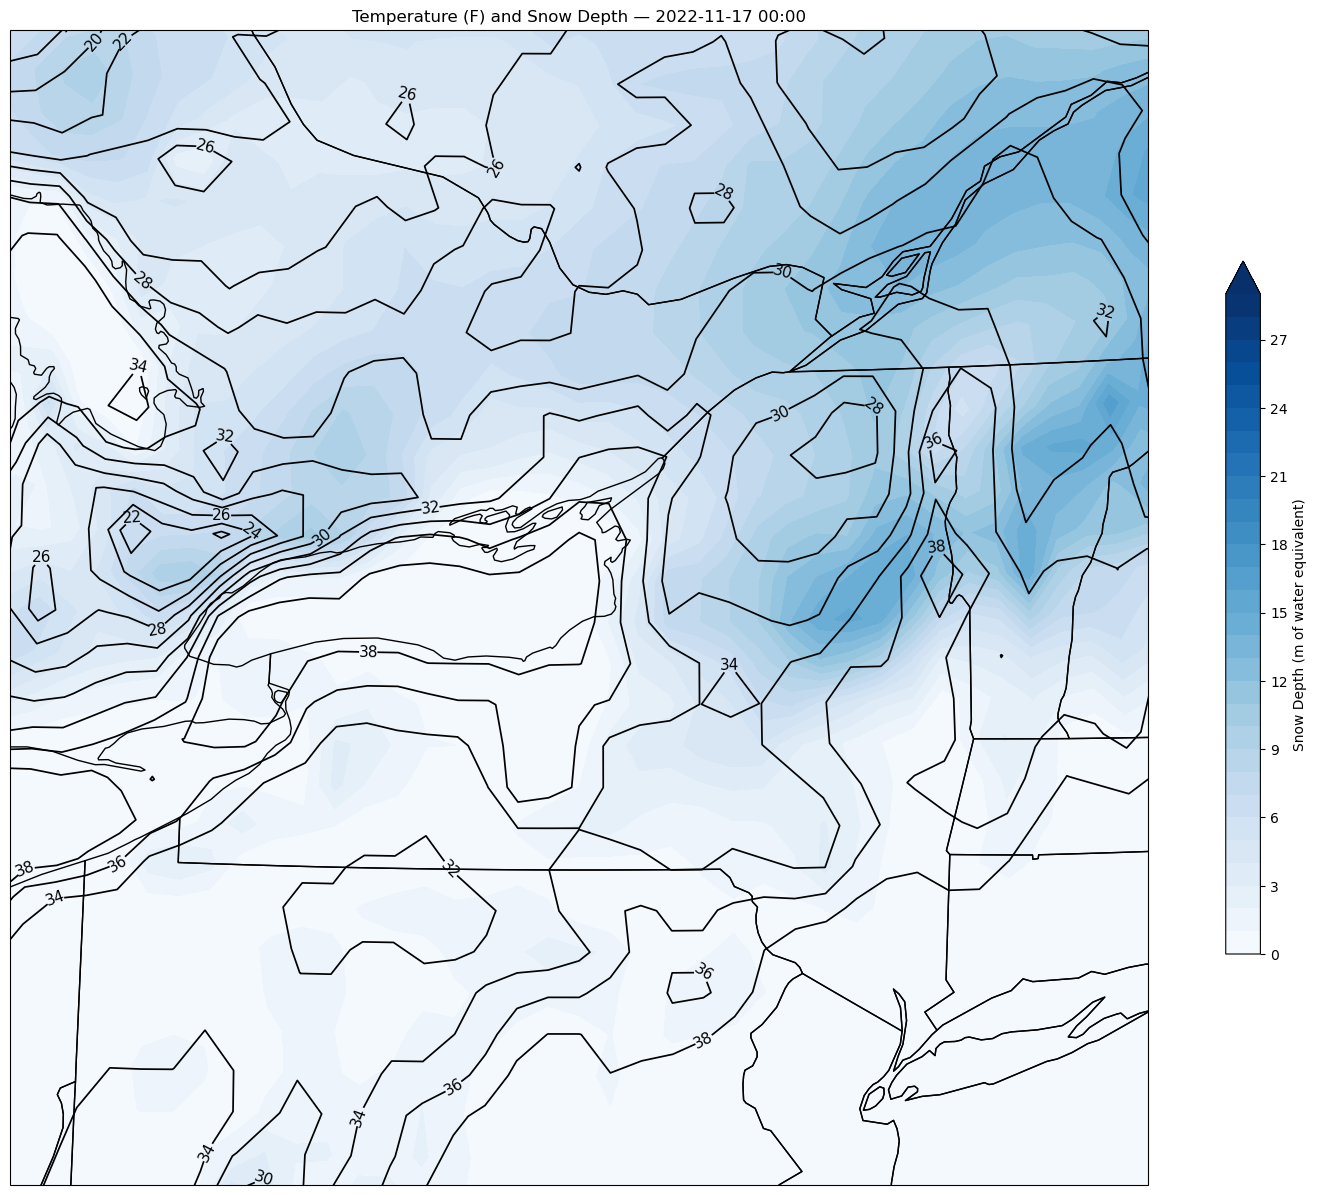

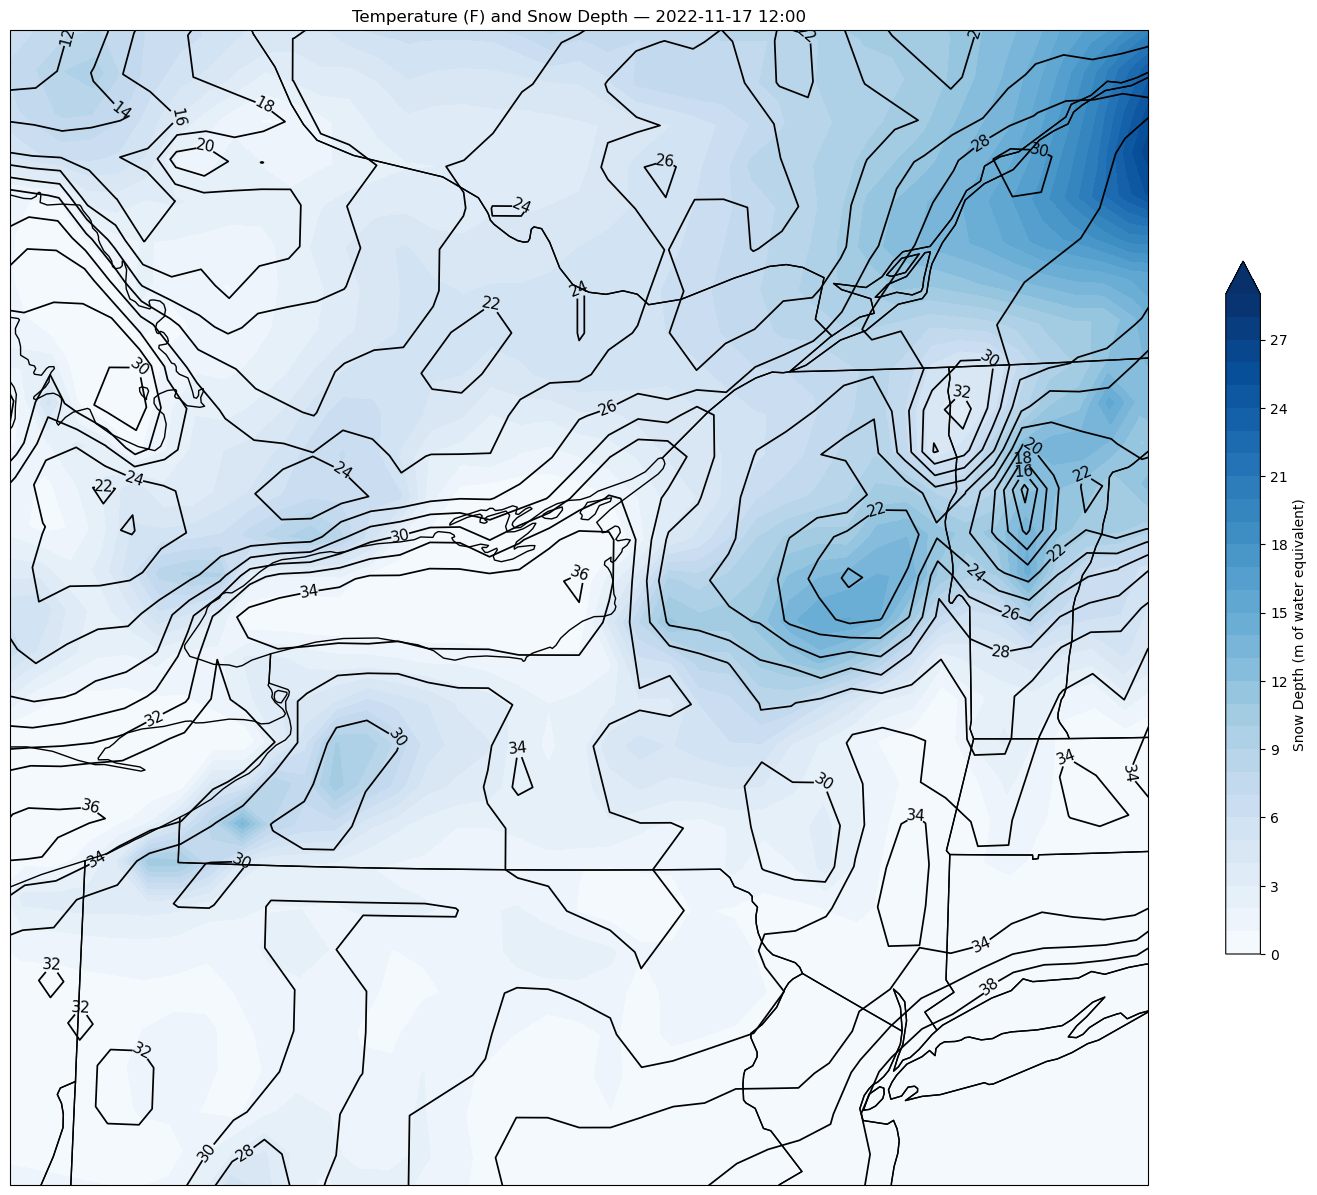

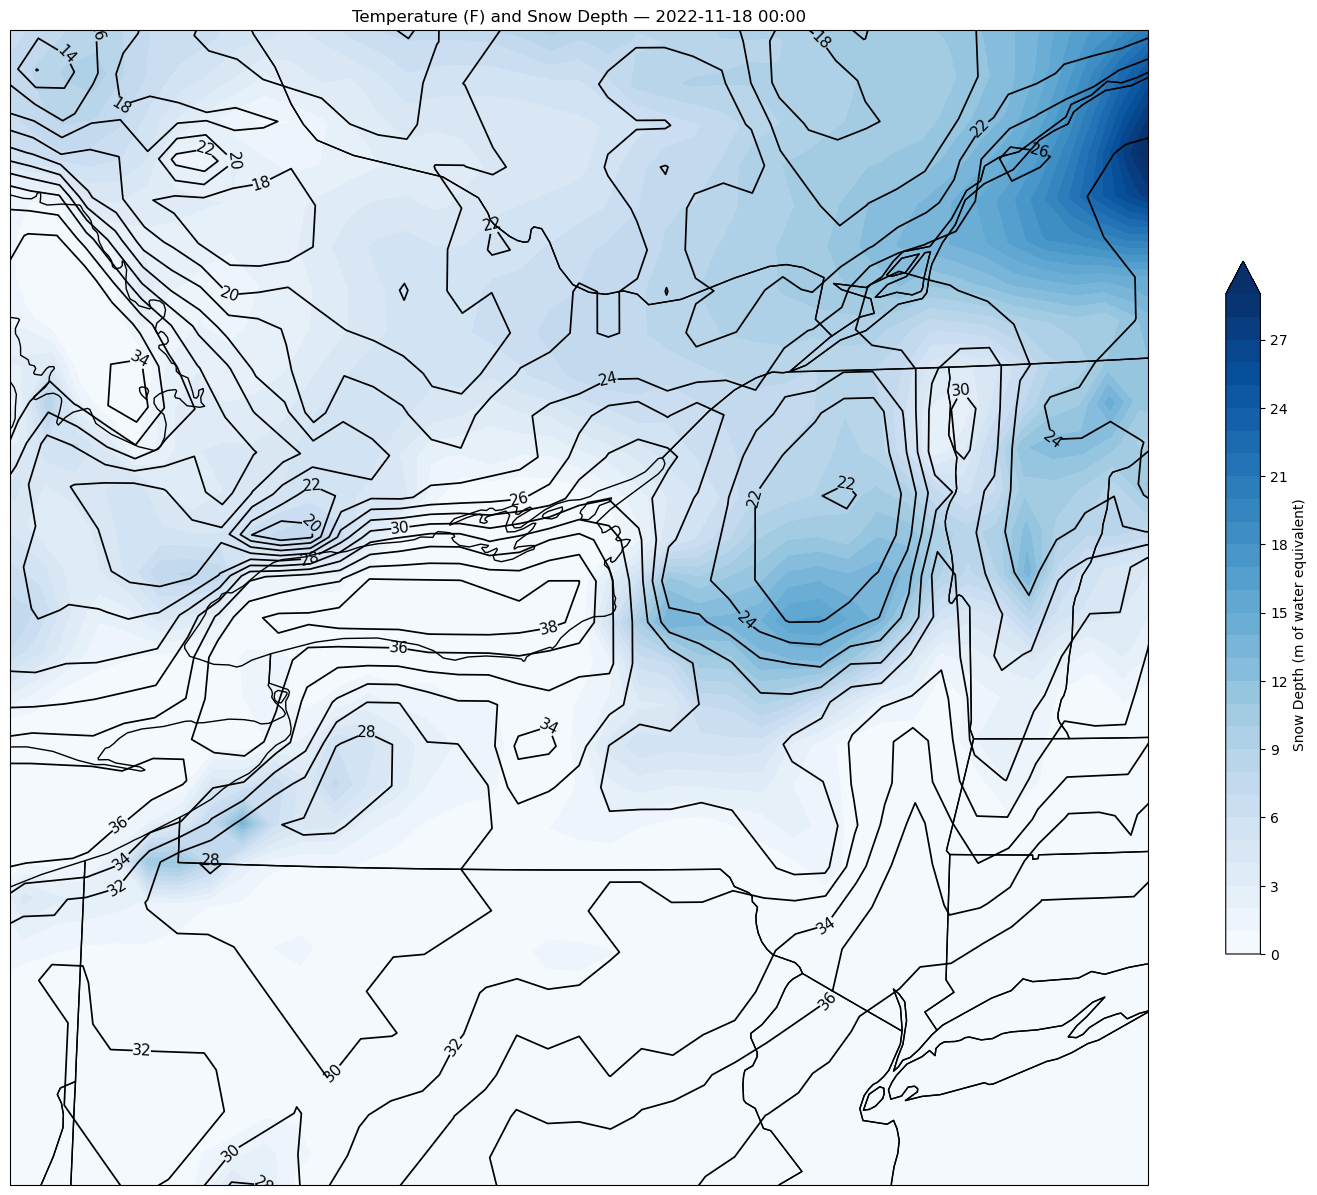

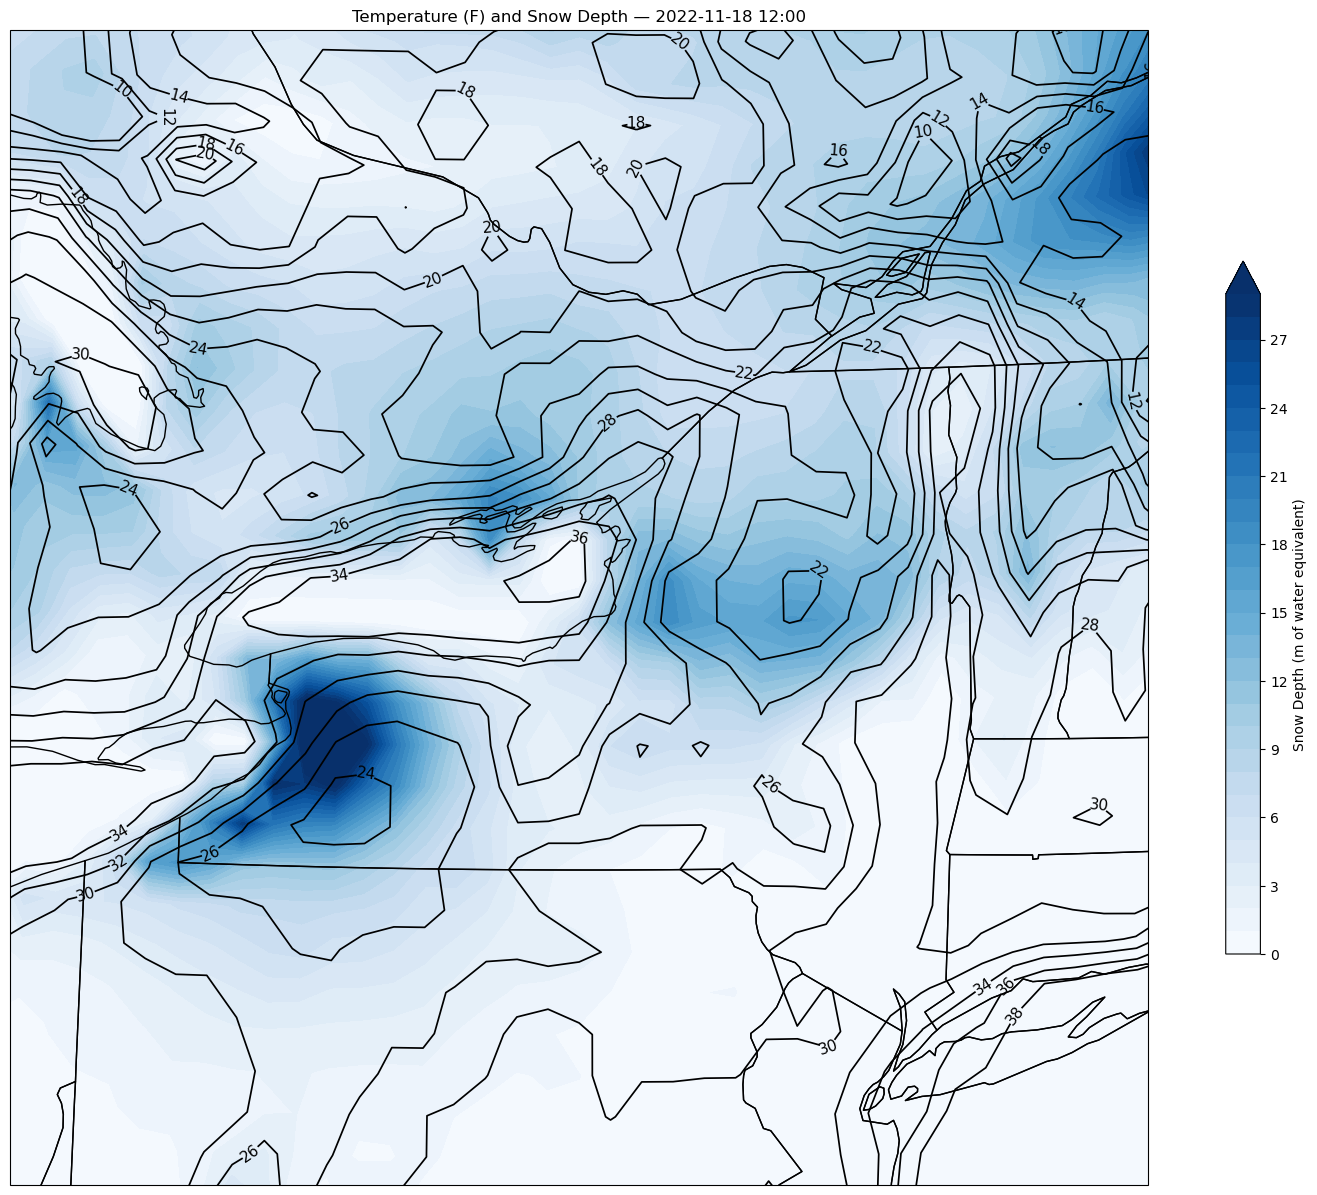

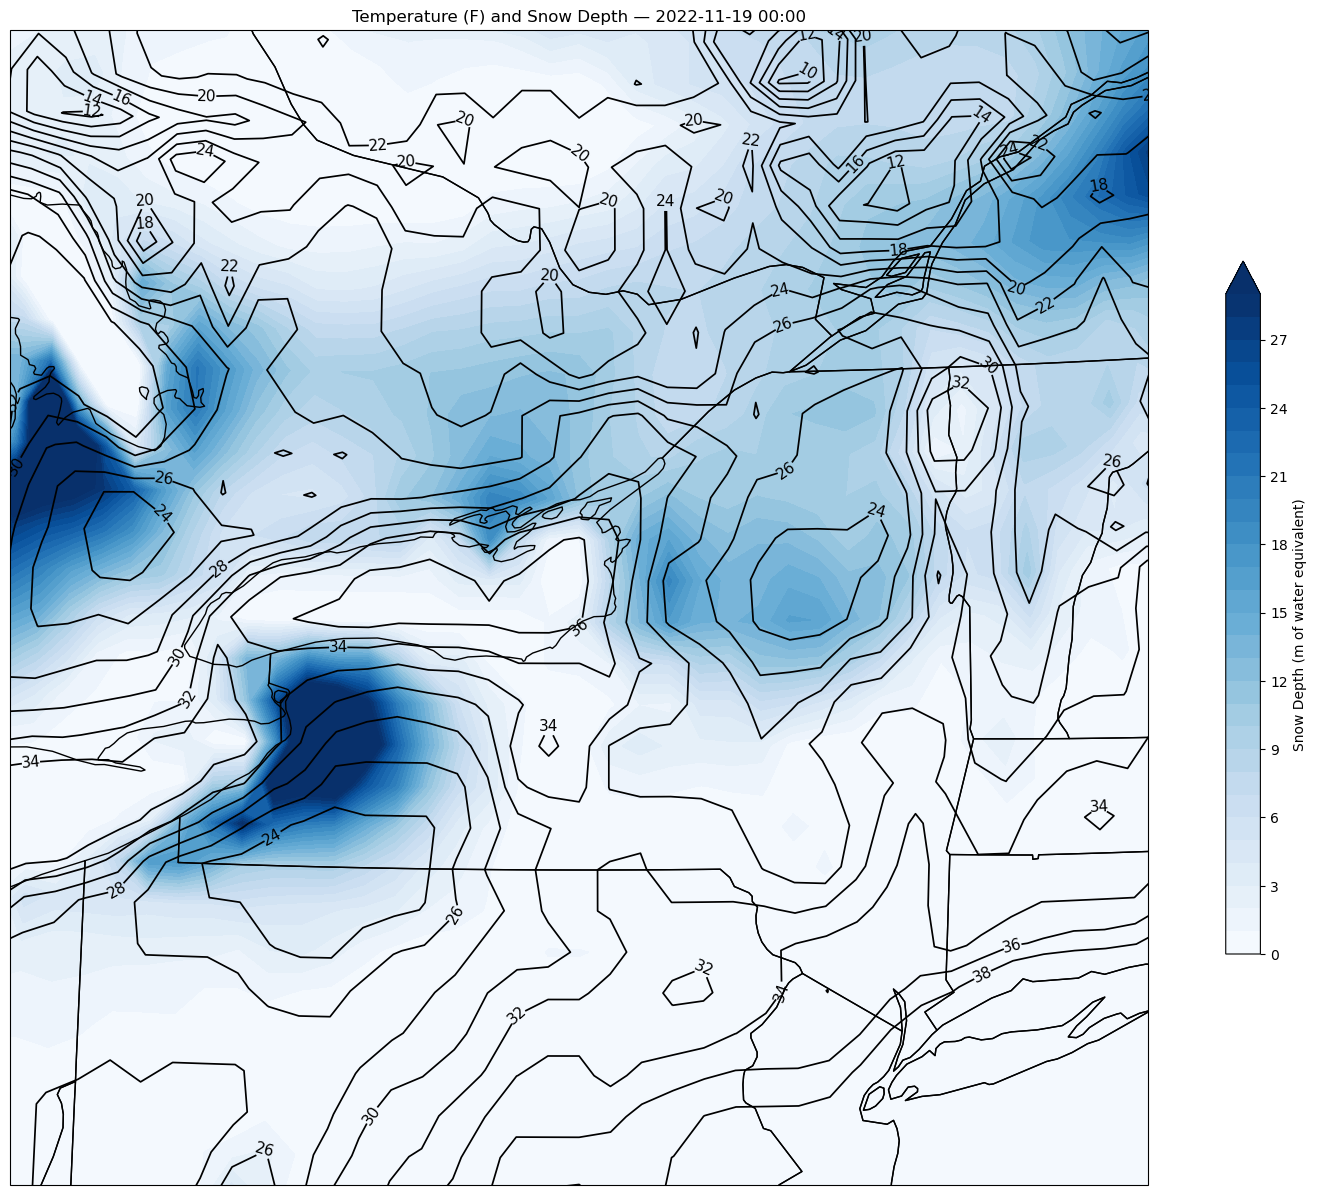

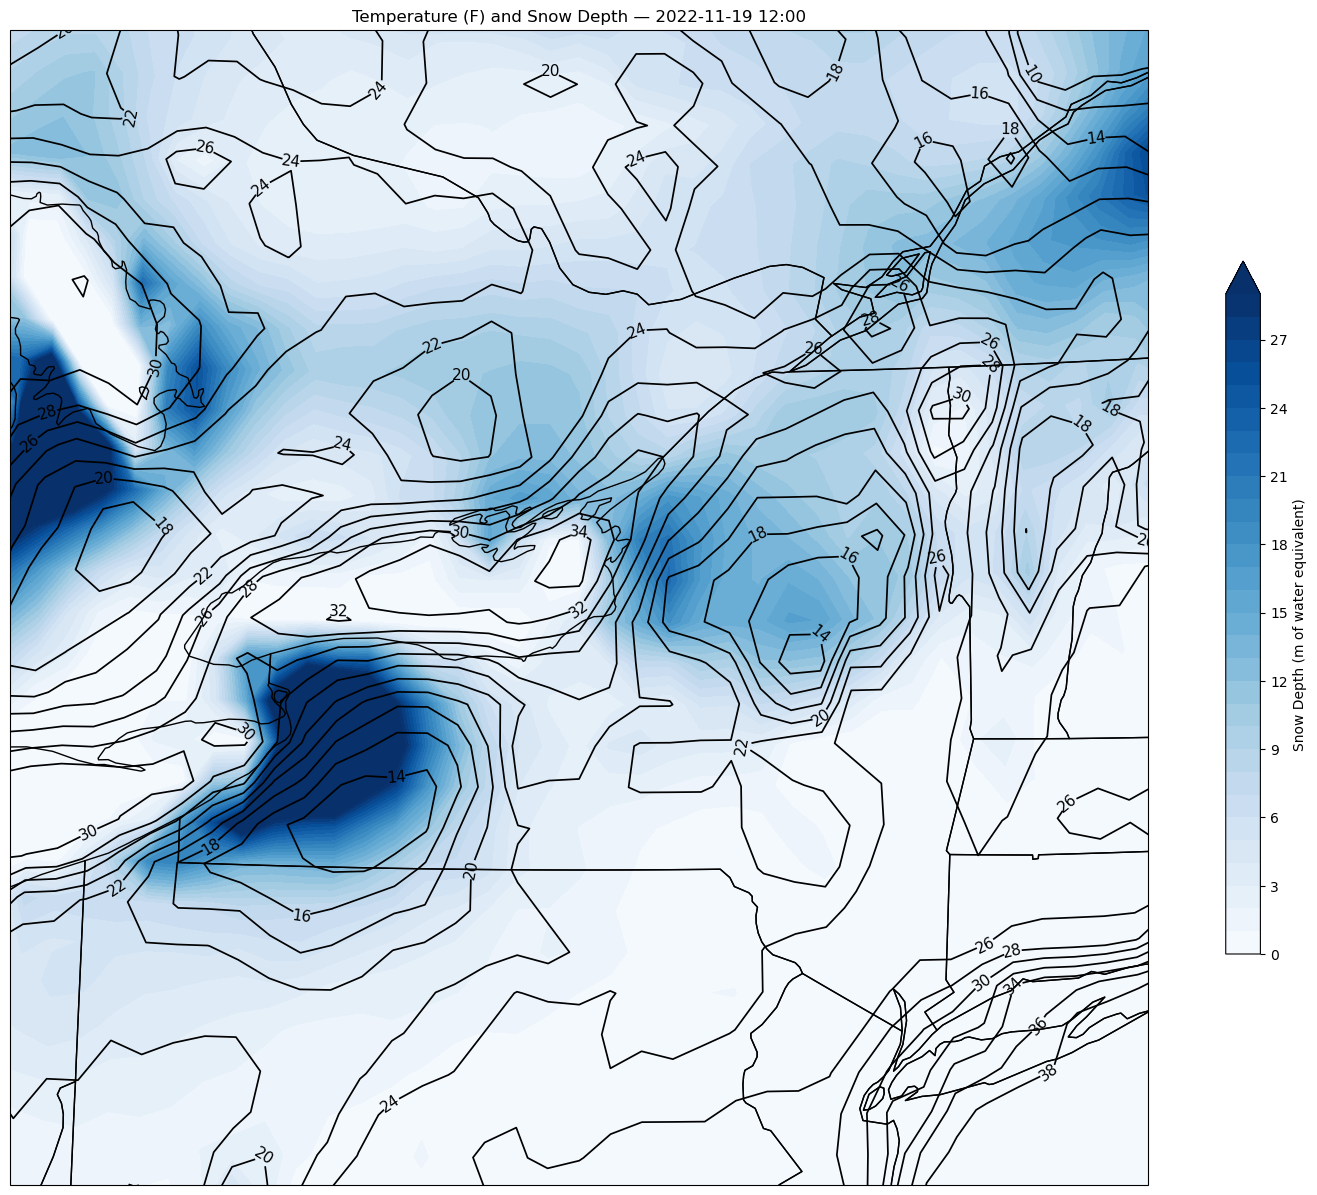

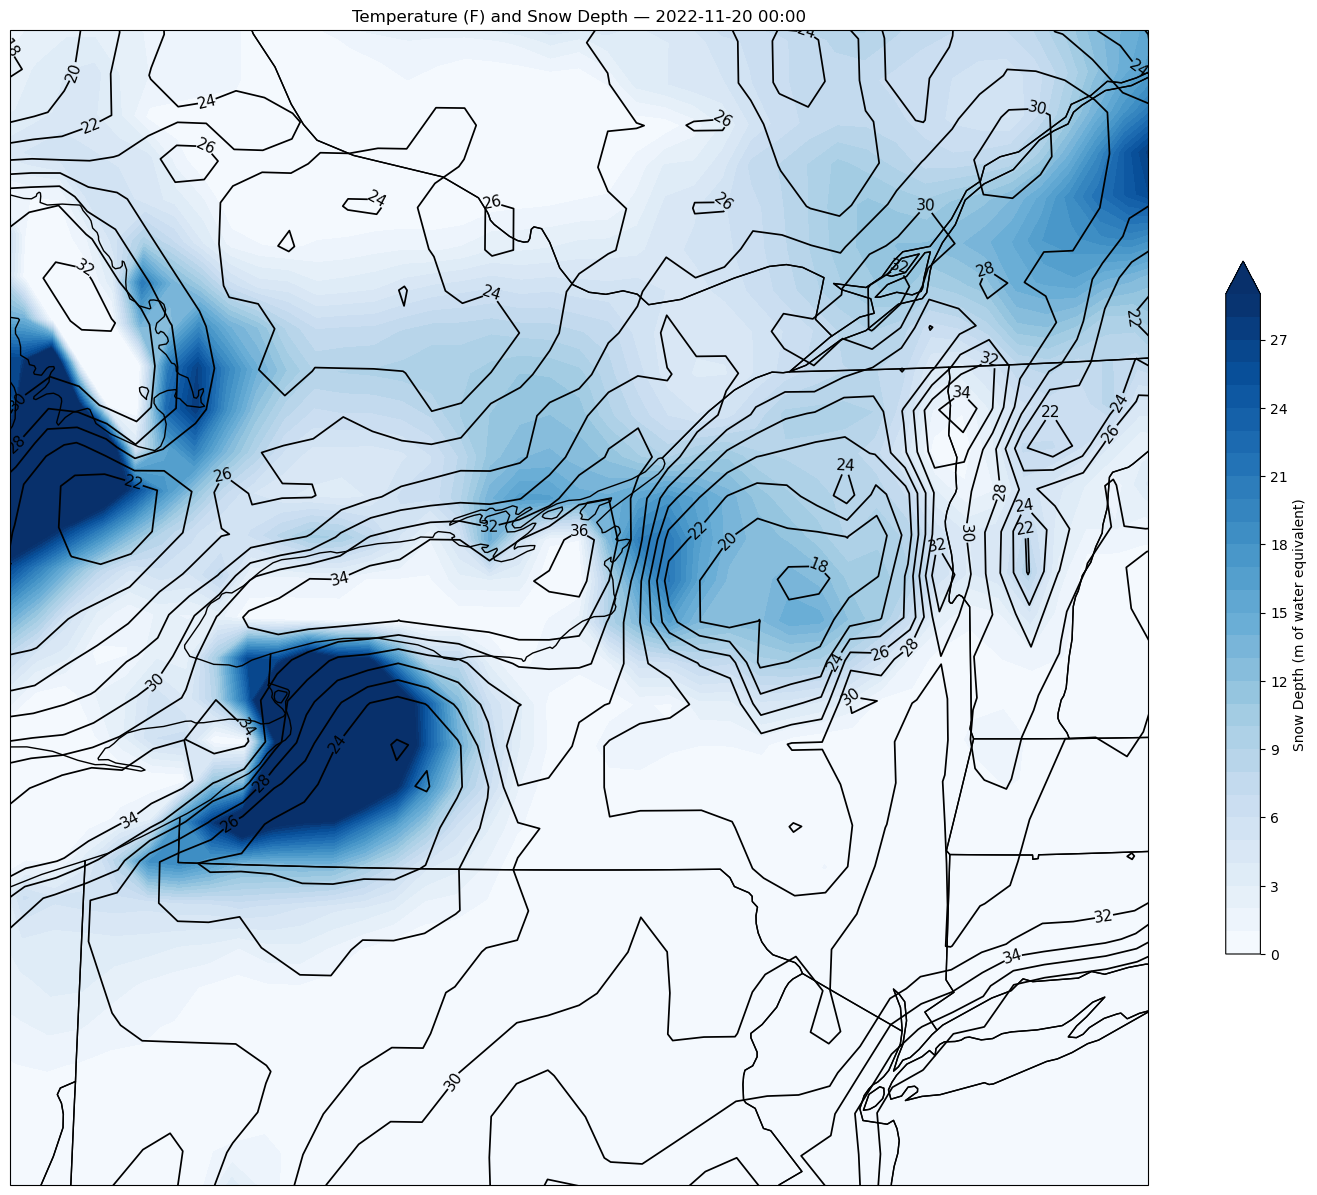

In [6]:
proj_map = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)
proj_data = ccrs.PlateCarree() 
res = '50m'

# some help making the loop skip every 12 hours with chatgpt!
for t in temp.valid_time.sel(valid_time=temp.valid_time.dt.hour.isin([0, 12])):
    fig, ax = plt.subplots(subplot_kw={'projection': proj_map}, figsize=(20,15))
    ax.set_extent([lonW, lonE, latS, latN])
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.add_feature(cfeature.STATES.with_scale(res))
    
    tint = np.arange(10,40,2)
    CL = ax.contour(lons, lats, temp.sel(valid_time=t), levels=tint, transform=proj_data,
                    linewidths=1.25, colors='black')
    sint = np.arange(0,30,1)
    CF = ax.contourf(lons, lats, depth.sel(valid_time=t), levels=sint,transform=proj_data,
                     cmap='Blues', extend='max')
    cbar = fig.colorbar(CF,shrink=0.6,label = 'Snow Depth (m of water equivalent)')
    clabel = ax.clabel(CL, inline_spacing=0.2, fontsize=11, fmt='%.0f')

    ax.set_title(f"Temperature (F) and Snow Depth — {t.dt.strftime('%Y-%m-%d %H:%M').item()}")
    plt.show()